In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = {
    'Product_ID': ['P001','P002','P003','P004','P005','P006','P007','P008'],
    'Product_Name': ['Paracetamol','Amoxicillin','Cetrizine','Insulin','Vitamin D3','Azithromycin','Metformin','Calcium'],
    'Category': ['OTC','Antibiotic','OTC','Hormone','Supplement','Antibiotic','Diabetic','Supplement'],
    'Units_Sold': [1200, 850, 1400, 500, 950, 670, 780, 890],
    'Unit_Price': [10, 25, 8, 120, 15, 30, 22, 18],
    'Region': ['North','South','East','West','North','South','East','West'],
    'Stock_Remaining': [300, 150, 400, 200, 350, 180, 220, 280]
}

df = pd.DataFrame(data)
df

,Product_ID,Product_Name,Category,Units_Sold,Unit_Price,Region,Stock_Remaining
0,P001,Paracetamol,OTC,1200,10,North,300
1,P002,Amoxicillin,Antibiotic,850,25,South,150
2,P003,Cetrizine,OTC,1400,8,East,400
3,P004,Insulin,Hormone,500,120,West,200
4,P005,Vitamin D3,Supplement,950,15,North,350
5,P006,Azithromycin,Antibiotic,670,30,South,180
6,P007,Metformin,Diabetic,780,22,East,220
7,P008,Calcium,Supplement,890,18,West,280


In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       8 non-null      object
 1   Product_Name     8 non-null      object
 2   Category         8 non-null      object
 3   Units_Sold       8 non-null      int64 
 4   Unit_Price       8 non-null      int64 
 5   Region           8 non-null      object
 6   Stock_Remaining  8 non-null      int64 
dtypes: int64(3), object(4)
memory usage: 576.0+ bytes
None
        Units_Sold  Unit_Price  Stock_Remaining
count     8.000000    8.000000         8.000000
mean    905.000000   31.000000       260.000000
std     285.907078   36.711228        87.341694
min     500.000000    8.000000       150.000000
25%     752.500000   13.750000       195.000000
50%     870.000000   20.000000       250.000000
75%    1012.500000   26.250000       312.500000
max    1400.000000  120.000000       400.000000
Pro

In [4]:
df['Total_Sales'] = df['Units_Sold'] * df['Unit_Price']
df.head()

,Product_ID,Product_Name,Category,Units_Sold,Unit_Price,Region,Stock_Remaining,Total_Sales
0,P001,Paracetamol,OTC,1200,10,North,300,12000
1,P002,Amoxicillin,Antibiotic,850,25,South,150,21250
2,P003,Cetrizine,OTC,1400,8,East,400,11200
3,P004,Insulin,Hormone,500,120,West,200,60000
4,P005,Vitamin D3,Supplement,950,15,North,350,14250


In [5]:
# Top 3 best-selling products by total sales
top_products = df.sort_values(by='Total_Sales', ascending=False).head(3)
print("Top 3 Products by Sales:")
print(top_products[['Product_Name','Total_Sales']])

# Least 3 selling products
bottom_products = df.sort_values(by='Total_Sales').head(3)
print("\nBottom 3 Products by Sales:")
print(bottom_products[['Product_Name','Total_Sales']])

Top 3 Products by Sales:
   Product_Name  Total_Sales
3       Insulin        60000
1   Amoxicillin        21250
5  Azithromycin        20100

Bottom 3 Products by Sales:
  Product_Name  Total_Sales
2    Cetrizine        11200
0  Paracetamol        12000
4   Vitamin D3        14250


In [6]:
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Hormone       60000
Antibiotic    41350
Supplement    30270
OTC           23200
Diabetic      17160
Name: Total_Sales, dtype: int64


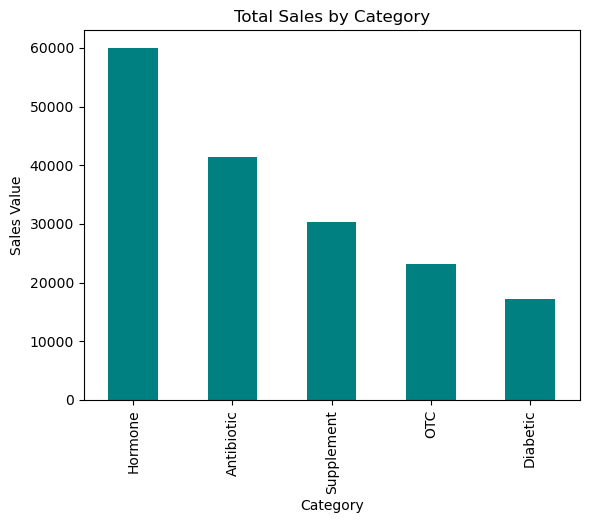

In [7]:
category_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales Value')
plt.show()

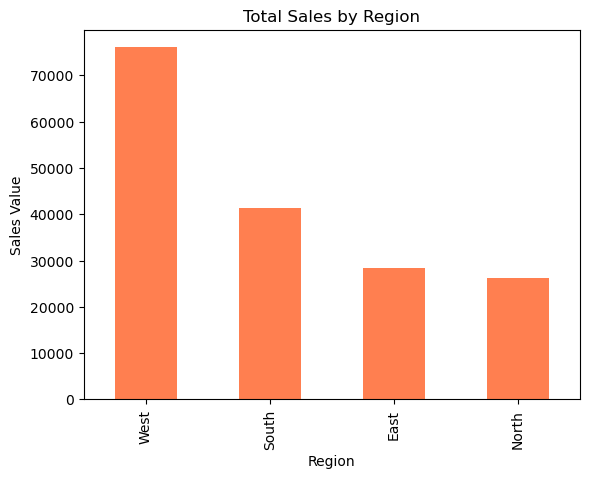

In [8]:
region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales Value')
plt.show()

In [9]:
df['Stock_to_Sales_Ratio'] = df['Stock_Remaining'] / df['Units_Sold']
low_stock = df[df['Stock_to_Sales_Ratio'] < 0.3]
print("Products with low stock ratio:")
print(low_stock[['Product_Name','Stock_Remaining','Units_Sold','Stock_to_Sales_Ratio']])

Products with low stock ratio:
   Product_Name  Stock_Remaining  Units_Sold  Stock_to_Sales_Ratio
0   Paracetamol              300        1200              0.250000
1   Amoxicillin              150         850              0.176471
2     Cetrizine              400        1400              0.285714
5  Azithromycin              180         670              0.268657
6     Metformin              220         780              0.282051


In [11]:
print("Key Insights:")
print(f"- Top selling product: {top_products.iloc[0]['Product_Name']} with sales of ₹{top_products.iloc[0]['Total_Sales']}")
print(f"- Best performing category: {category_sales.idxmax()} with total sales ₹{category_sales.max()}")
print(f"- Region with highest revenue: {region_sales.idxmax()}")
print(f"- {len(low_stock)} products need restocking soon.")


Key Insights:
- Top selling product: Insulin with sales of ₹60000
- Best performing category: Hormone with total sales ₹60000
- Region with highest revenue: West
- 5 products need restocking soon.


In [12]:
df.to_csv("pharma_sales_analysis.csv", index=False)